In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [ ]:
# ВХІДНІ ДАНІ (Варіант 5)

x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
y = np.array([1.0, 3.0, 5.0, 7.0, 9.0, 11.0, 13.0, 15.0])
N = len(x)

print("ЛАБОРАТОРНА РОБОТА №1 (Варіант 5)")
print("=" * 60)

ЛАБОРАТОРНА РОБОТА №1 (Варіант 5)


In [3]:
# ПУНКТ 1: Апроксимація поліномом 2-го порядку P(x) = a + b*x + c*x^2

# 1.1 Ручний розрахунок через систему нормальних рівнянь МНК (вирази 4-9)

M = np.array([
    [N,           np.sum(x),      np.sum(x**2)],
    [np.sum(x),   np.sum(x**2),   np.sum(x**3)],
    [np.sum(x**2), np.sum(x**3),  np.sum(x**4)]
])

V = np.array([
    np.sum(y),
    np.sum(x * y),
    np.sum(x**2 * y)
])

# Розв'язання СЛАР M * [a, b, c]^T = V
a_manual, b_manual, c_manual = np.linalg.solve(M, V)

In [4]:
# 1.2 Розрахунок за допомогою вбудованої функції np.polyfit (аналог polyfit в MATLAB)
poly_coeffs = np.polyfit(x, y, deg=2)
c_builtin, b_builtin, a_builtin = poly_coeffs[0], poly_coeffs[1], poly_coeffs[2]

print("\n--- 1. АПРОКСИМАЦІЯ ПОЛІНОМОМ 2-ГО ПОРЯДКУ ---")
print(f"Аналітичний розрахунок (МНК): P(x) = {a_manual:.4f} + ({b_manual:.4f})*x + ({c_manual:.4f})*x^2")
print(f"Бібліотечна np.polyfit:       P(x) = {a_builtin:.4f} + ({b_builtin:.4f})*x + ({c_builtin:.4f})*x^2")
print(f"Різниця коефіцієнтів: |Δa| = {abs(a_manual - a_builtin):.2e}, |Δb| = {abs(b_manual - b_builtin):.2e}, |Δc| = {abs(c_manual - c_builtin):.2e}")


--- 1. АПРОКСИМАЦІЯ ПОЛІНОМОМ 2-ГО ПОРЯДКУ ---
Аналітичний розрахунок (МНК): P(x) = -1.0000 + (2.0000)*x + (0.0000)*x^2
Бібліотечна np.polyfit:       P(x) = -1.0000 + (2.0000)*x + (-0.0000)*x^2
Різниця коефіцієнтів: |Δa| = 2.00e-15, |Δb| = 1.33e-15, |Δc| = 2.55e-16


In [5]:
# ПУНКТ 2: Кубічний сплайн (вирази 12-27)
h = np.diff(x)  # h_n = x_{n+1} - x_n

num_inner = N - 2
A_spline = np.zeros((num_inner, num_inner))
B_spline = np.zeros(num_inner)

for i in range(num_inner):
    n = i + 1
    A_spline[i, i] = 2.0 * (h[n - 1] + h[n])

    if i > 0:
        A_spline[i, i - 1] = h[n - 1]

    if i < num_inner - 1:
        A_spline[i, i + 1] = h[n]

    B_spline[i] = -6.0 / h[n - 1] * (y[n] - y[n - 1]) + 6.0 / h[n] * (y[n + 1] - y[n])

y_double_prime_inner = np.linalg.solve(A_spline, B_spline)

y_pp = np.zeros(N)
y_pp[1:-1] = y_double_prime_inner

coeffs_manual = []
for n in range(N - 1):
    an = y[n]
    bn = (y[n + 1] - y[n]) / h[n] - (h[n] / 6.0) * (y_pp[n + 1] + 2.0 * y_pp[n])
    cn = 0.5 * y_pp[n]
    dn = (y_pp[n + 1] - y_pp[n]) / (6.0 * h[n])
    coeffs_manual.append((an, bn, cn, dn))

cs_builtin = CubicSpline(x, y, bc_type='natural')

print("\n--- 2. КУБІЧНИЙ СПЛАЙН (КОЕФІЦІЄНТИ ВІДРІЗКІВ) ---")
for n, (an, bn, cn, dn) in enumerate(coeffs_manual, start=1):
    print(f"Сегмент {n} [x={x[n-1]:.1f}..{x[n]:.1f}]: P_{n}(x) = {an:.2f} + {bn:.2f}*(x - {x[n-1]:.1f}) + {cn:.2f}*(x - {x[n-1]:.1f})^2 + {dn:.2f}*(x - {x[n-1]:.1f})^3")


--- 2. КУБІЧНИЙ СПЛАЙН (КОЕФІЦІЄНТИ ВІДРІЗКІВ) ---
Сегмент 1 [x=1.0..2.0]: P_1(x) = 1.00 + 2.00*(x - 1.0) + 0.00*(x - 1.0)^2 + 0.00*(x - 1.0)^3
Сегмент 2 [x=2.0..3.0]: P_2(x) = 3.00 + 2.00*(x - 2.0) + 0.00*(x - 2.0)^2 + 0.00*(x - 2.0)^3
Сегмент 3 [x=3.0..4.0]: P_3(x) = 5.00 + 2.00*(x - 3.0) + 0.00*(x - 3.0)^2 + 0.00*(x - 3.0)^3
Сегмент 4 [x=4.0..5.0]: P_4(x) = 7.00 + 2.00*(x - 4.0) + 0.00*(x - 4.0)^2 + 0.00*(x - 4.0)^3
Сегмент 5 [x=5.0..6.0]: P_5(x) = 9.00 + 2.00*(x - 5.0) + 0.00*(x - 5.0)^2 + 0.00*(x - 5.0)^3
Сегмент 6 [x=6.0..7.0]: P_6(x) = 11.00 + 2.00*(x - 6.0) + 0.00*(x - 6.0)^2 + 0.00*(x - 6.0)^3
Сегмент 7 [x=7.0..8.0]: P_7(x) = 13.00 + 2.00*(x - 7.0) + 0.00*(x - 7.0)^2 + 0.00*(x - 7.0)^3


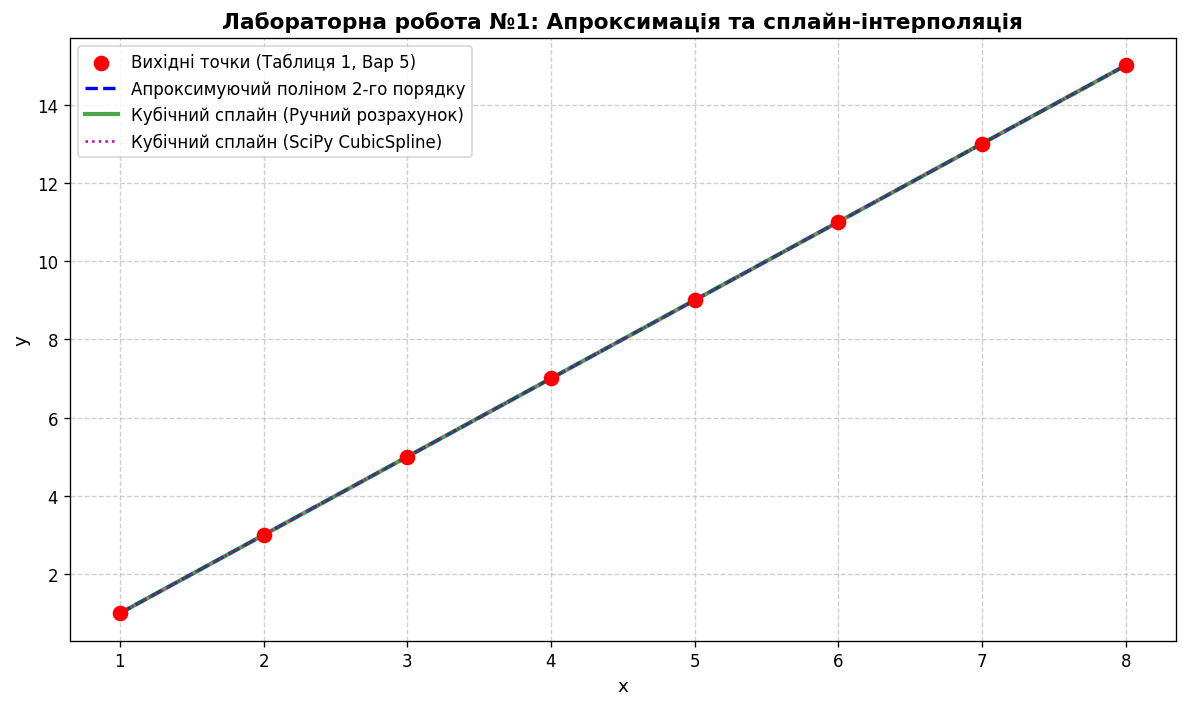


Максимальне відхилення між ручним та бібліотечним сплайном: 0.00e+00


In [6]:
# ПУНКТ 3: Побудова графіків

x_dense = np.linspace(x[0], x[-1], 500)

# Обчислення полінома
y_poly_dense = a_manual + b_manual * x_dense + c_manual * (x_dense**2)

# Обчислення ручного сплайна
def evaluate_manual_spline(x_val):
    if x_val >= x[-1]:
        an, bn, cn, dn = coeffs_manual[-1]
        dx = x_val - x[-2]
        return an + bn * dx + cn * (dx**2) + dn * (dx**3)
    for i in range(len(x) - 1):
        if x[i] <= x_val <= x[i + 1]:
            an, bn, cn, dn = coeffs_manual[i]
            dx = x_val - x[i]
            return an + bn * dx + cn * (dx**2) + dn * (dx**3)
    return 0.0

y_spline_manual_dense = np.array([evaluate_manual_spline(val) for val in x_dense])
y_spline_builtin_dense = cs_builtin(x_dense)

plt.figure(figsize=(10, 6), dpi=120)
plt.scatter(x, y, color='red', s=70, zorder=5, label='Вихідні точки (Таблиця 1, Вар 5)')
plt.plot(x_dense, y_poly_dense, 'b--', linewidth=2, label=f'Апроксимуючий поліном 2-го порядку')
plt.plot(x_dense, y_spline_manual_dense, 'g-', linewidth=2.5, alpha=0.7, label='Кубічний сплайн (Ручний розрахунок)')
plt.plot(x_dense, y_spline_builtin_dense, 'm:', linewidth=1.5, label='Кубічний сплайн (SciPy CubicSpline)')

plt.title('Лабораторна робота №1: Апроксимація та сплайн-інтерполяція', fontsize=13, fontweight='bold')
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('lab1_plot.png', dpi=300)
plt.show()

# Перевірка максимального розходження
max_diff = np.max(np.abs(y_spline_manual_dense - y_spline_builtin_dense))
print(f"\nМаксимальне відхилення між ручним та бібліотечним сплайном: {max_diff:.2e}")